# Comparative Study of Crossover Strategies in a Genetic Algorithm

This notebook implements and compares different crossover strategies in a controlled environment while keeping the remaining Genetic Algorithm parameters fixed (selection = tournament, mutation = baseline hybrid mutation, elitism = 10%).

The main objective is to evaluate how different crossover operators influence the convergence behavior, optimization performance, and population diversity of the Genetic Algorithm in an image approximation task using semi-transparent triangles.

Four crossover strategies are tested:
- **One-Point** — standard crossover with a single random split point
- **Uniform** — independent triangle-by-triangle recombination
- **None** — baseline without crossover, isolating the contribution of mutation
- **Spatial** — original strategy that combines triangles based on their position in the image

To ensure statistical robustness, each configuration is executed across multiple random seeds and analyzed using hypothesis testing (Kruskal-Wallis and Mann-Whitney U with Bonferroni correction).

In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from itertools import combinations

SEEDS = [42, 123, 456, 789, 1024]

## 1. Configuration

All parameters below are fixed across the four experiments. Only the crossover type varies, ensuring a fair and isolated comparison.



In [13]:
POP_SIZE = 30
GENERATIONS = 1000

ELITE_SIZE = 3
TOURNAMENT_SIZE = 5

CROSSOVER_TYPES = [
    "one_point",
    "uniform",
    "none",
    "spatial"
]

In [14]:
def load_target_image(filepath):
    """Loads the target image, resizes it and converts it from BGR to RGB."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Image {filepath} not found.")

    img = cv2.imread(filepath)

    if img is None:
        raise ValueError(f"Could not read image file: {filepath}")

    img = cv2.resize(img, (WIDTH, HEIGHT))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img

In [15]:
def one_point_crossover(parent_1, parent_2):
    """Performs one-point crossover."""
    split = random.randint(1, NUM_TRIANGLES - 1)

    child = parent_1[:split] + parent_2[split:]

    return [triangle.copy() for triangle in child]


def uniform_crossover(parent_1, parent_2):
    """Performs uniform crossover."""
    child = []

    for tri_1, tri_2 in zip(parent_1, parent_2):
        if random.random() < 0.5:
            child.append(tri_1.copy())
        else:
            child.append(tri_2.copy())

    return child

def spatial_crossover(parent_1, parent_2):
    """Crossover by spatial zone of the image.
    Triangles whose center is in the upper half of the image come from parent 1.
    Triangles whose center is in the lower half come from parent 2.
    Exploits the fact that triangles cover distinct spatial zones."""
    child = []

    for tri_1, tri_2 in zip(parent_1, parent_2):
        # Calculate center of triangle from parent 1
        cx = (tri_1["p1"][0] + tri_1["p2"][0] + tri_1["p3"][0]) / 3
        cy = (tri_1["p1"][1] + tri_1["p2"][1] + tri_1["p3"][1]) / 3
        
        # Upper half from parent 1, lower half from parent 2
        if cy < HEIGHT / 2:
            child.append(tri_1.copy())
        else:
            child.append(tri_2.copy())
    return child

def no_crossover(parent_1, parent_2):
    """No crossover - child is a copy of parent 1, only mutation applies.
    Used to evaluate the isolated contribution of crossover."""
    return [triangle.copy() for triangle in parent_1]

def apply_crossover(
    parent_1,
    parent_2,
    crossover_type="one_point"
):
    """Applies the selected crossover strategy."""
    if crossover_type == "one_point":
        return one_point_crossover(parent_1, parent_2)

    if crossover_type == "uniform":
        return uniform_crossover(parent_1, parent_2)
    
    if crossover_type == "none":
        return no_crossover(parent_1, parent_2)
    
    if crossover_type == "spatial":
        return spatial_crossover(parent_1, parent_2)

    raise ValueError(f"Unknown crossover type: {crossover_type}")


In [16]:
def evolve_configurable(
    target_img,
    pop_size=30,
    generations=300,
    mutation_rate=0.05,
    elite_size=3,
    selection_type="tournament",
    tournament_size=5,
    crossover_type="one_point",
    crossover_rate=0.9,
    use_mutation_decay=False,
    min_mutation_rate=0.01,
    snapshot_generations=None,
    print_every=None,
    track_diversity=False
):
    """
    Runs a configurable Genetic Algorithm.
    Supports different selection, crossover and mutation configurations.
    """
    background_color = get_background_color(target_img)

    population = [
        create_random_individual(target_img)
        for _ in range(pop_size)
    ]

    best_fitness_history = []
    mutation_rate_history = []
    snapshots = {}

    if snapshot_generations is None:
        snapshot_generations = []

    snapshot_generations = set(
        gen for gen in snapshot_generations
        if 0 <= gen < generations
    )

    best_individual = None
    diversity_history = []

    for gen in range(generations):
        rendered_images = [
            render_individual(ind, background_color)
            for ind in population
        ]

        fitnesses = [
            calculate_fitness(rendered, target_img)
            for rendered in rendered_images
        ]

        sorted_indices = np.argsort(fitnesses)

        population = [
            population[i]
            for i in sorted_indices
        ]

        fitnesses = [
            fitnesses[i]
            for i in sorted_indices
        ]

        current_best_fit = fitnesses[0]
        best_individual = population[0]

        best_fitness_history.append(current_best_fit)

        if track_diversity:
            diversity_history.append(genotypic_variance(population))

        
        if use_mutation_decay:
            current_mutation_rate = max(
                min_mutation_rate,
                mutation_rate * (1 - gen / generations)
            )
        else:
            current_mutation_rate = mutation_rate

        mutation_rate_history.append(current_mutation_rate)

        if gen in snapshot_generations:
            best_rendered = render_individual(
                best_individual,
                background_color
            )

            snapshots[gen] = {
                "image": best_rendered.copy(),
                "rmse": current_best_fit,
                "mutation_rate": current_mutation_rate
            }

        new_population = [
            individual.copy()
            for individual in population[:elite_size]
        ]

        while len(new_population) < pop_size:
            parent_1 = select_parent(
                population,
                fitnesses,
                selection_type=selection_type,
                tournament_size=tournament_size
            )

            parent_2 = select_parent(
                population,
                fitnesses,
                selection_type=selection_type,
                tournament_size=tournament_size
            )

            if random.random() < crossover_rate:
                child = apply_crossover(
                    parent_1,
                    parent_2,
                    crossover_type=crossover_type
                )
            else:
                child = [
                    triangle.copy()
                    for triangle in parent_1
                ]

            child = mutate(
                child,
                target_img,
                current_mutation_rate
            )

            new_population.append(child)

        population = new_population

        if print_every is not None:
            if gen % print_every == 0 or gen == generations - 1:
                print(
                    f"Generation {gen:05d} | "
                    f"Best RMSE: {current_best_fit:.4f} | "
                    f"Mutation: {current_mutation_rate:.4f}"
                )

    return {
        "best_individual": best_individual,
        "history": best_fitness_history,
        "background_color": background_color,
        "snapshots": snapshots,
        "mutation_rate_history": mutation_rate_history,
        "best_rmse": best_fitness_history[-1],
        "diversity_history": diversity_history if track_diversity else None
         }

## 2. Target Image

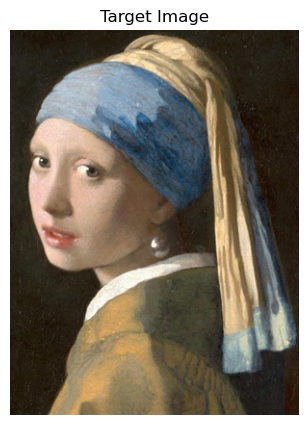

In [17]:
target = load_target_image("girl_pearl_earing.png")

plt.figure(figsize=(4, 5))
plt.imshow(target)
plt.title("Target Image")
plt.axis("off")
plt.show()

## 3. Experiment Function

The function below runs the GA for each crossover type. The four strategies tested are:

- `one_point` — splits the triangle list at a random position and combines both halves from different parents
- `uniform` — selects each triangle independently from either parent with 50% probability
- `none` — no recombination occurs, serving as a baseline to measure the isolated effect of mutation
- `spatial` — combines triangles based on their spatial position in the image (upper half from one parent, lower half from the other)

In [18]:
def run_crossover_experiment(
    target_img,
    crossover_types,
    seeds,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
):
    """
    Runs the GA with different crossover types and multiple seeds.
    All other GA parameters remain constant.
    """
    results = {}

    for crossover_type in crossover_types:
        results[crossover_type] = []
        for seed in seeds:
            print("=" * 60)
            print(f"Testing crossover type: {crossover_type} | Seed: {seed}")

            random.seed(seed)
            np.random.seed(seed)

            result = evolve_configurable(
                target_img=target_img,
                pop_size=pop_size,
                generations=generations,
                mutation_rate=0.05,
                elite_size=elite_size,
                selection_type="tournament",
                tournament_size=tournament_size,
                crossover_type=crossover_type,
                crossover_rate=0.9,
                use_mutation_decay=False,
                snapshot_generations=[0, generations - 1],
                print_every=100,
                track_diversity=True 
            )

            best_rend = render_individual(
                result["best_individual"],
                result["background_color"]
            )

            final_rmse = calculate_fitness(best_rend, target_img)

            results[crossover_type].append({
                "seed": seed,
                "history": result["history"],
                "background_color": result["background_color"],
                "final_image": best_rend,
                "final_rmse": final_rmse,
                "diversity_history": result["diversity_history"]
            })

            print(f"Final RMSE: {final_rmse:.4f}")

    return results

## 4. Running the Experiments

Each crossover strategy is evaluated using a fixed crossover rate of 0.9 while keeping all remaining Genetic Algorithm parameters constant.

To improve the reliability of the comparison, each configuration is executed across 5 random seeds. During execution, the best RMSE and population diversity values are recorded throughout the generations.

In [19]:
crossover_results = run_crossover_experiment(
    target_img=target,
    crossover_types=CROSSOVER_TYPES,
    seeds=SEEDS,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    elite_size=ELITE_SIZE,
    tournament_size=TOURNAMENT_SIZE
)


Testing crossover type: one_point | Seed: 42
Generation 00000 | Best RMSE: 56.4600 | Mutation: 0.0500
Generation 00100 | Best RMSE: 40.7978 | Mutation: 0.0500


KeyboardInterrupt: 

## 5. Convergence Analysis

The plot below shows the evolution of the best RMSE throughout the generations for each crossover type, across all 5 seeds.

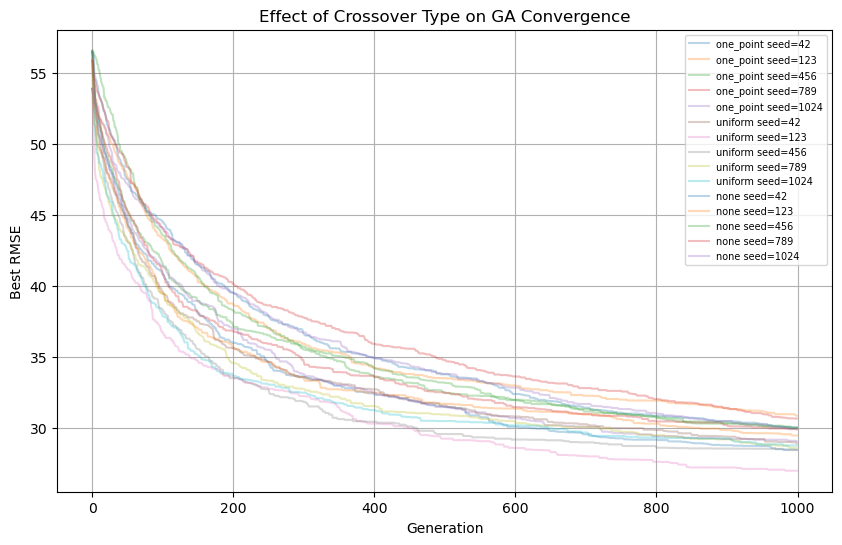

In [ ]:
plt.figure(figsize=(10, 6))
for crossover_type, runs in crossover_results.items():
    for run in runs:
        plt.plot(run["history"], alpha=0.3, 
                label=f"{crossover_type} seed={run['seed']}")
plt.title("Effect of Crossover Type on GA Convergence")
plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()

## 6. Best Generated Images

The images below show the best result obtained for each crossover type across all seeds.

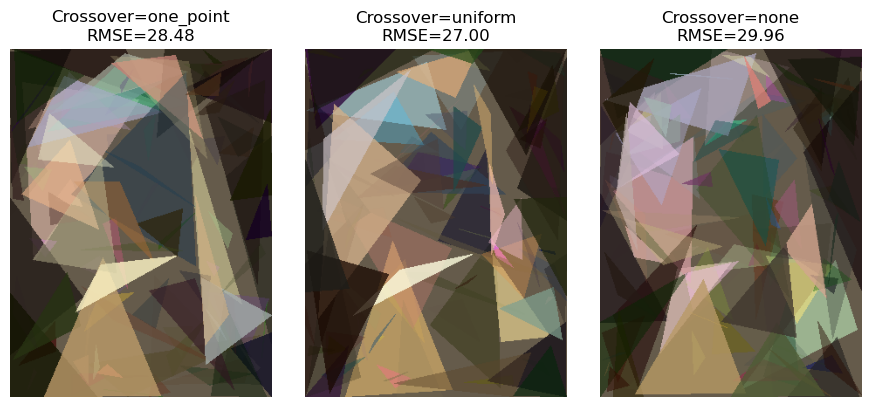

In [ ]:
fig, axes = plt.subplots(1, len(crossover_results), figsize=(3 * len(crossover_results), 4))
for ax, (crossover_type, runs) in zip(axes, crossover_results.items()):
    # Mostrar imagem do melhor seed
    best_run = min(runs, key=lambda r: r["final_rmse"])
    ax.imshow(best_run["final_image"])
    ax.set_title(f"Crossover={crossover_type}\nRMSE={best_run['final_rmse']:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Summary Table

Detailed results of every run including initial RMSE, final RMSE and total improvement.

In [ ]:
summary = []
for crossover_type, runs in crossover_results.items():
    for run in runs:
        summary.append({
            "Crossover Type": crossover_type,
            "Seed": run["seed"],
            "Final RMSE": run["final_rmse"],
            "Initial RMSE": run["history"][0],
            "Improvement": run["history"][0] - run["final_rmse"]
        })
summary_df = pd.DataFrame(summary)
summary_df

,Crossover Type,Seed,Final RMSE,Initial RMSE,Improvement
0,one_point,42,28.482712,56.460011,27.977299
1,one_point,123,29.486280,53.890099,24.403818
2,one_point,456,30.040409,56.567535,26.527126
3,one_point,789,29.899313,55.861862,25.962549
4,one_point,1024,29.073027,53.886505,24.813478
5,uniform,42,28.929930,56.460011,27.530081
6,uniform,123,27.001730,53.890099,26.888369
7,uniform,456,28.456352,56.567535,28.111183
8,uniform,789,28.606291,55.861862,27.255571
9,uniform,1024,28.774519,53.886505,25.111986


## 8. Genotypic Diversity Analysis

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_div = ['#1565C0', '#FF6F00', '#2E7D32', '#8E24AA']

for (crossover_type, runs), color in zip(crossover_results.items(), colors_div):
    all_diversity = np.array([run["diversity_history"] for run in runs])
    mean_div = np.mean(all_diversity, axis=0)
    std_div = np.std(all_diversity, axis=0)
    
    generations_axis = np.arange(len(mean_div))
    
    ax.plot(generations_axis, mean_div, label=crossover_type, color=color, linewidth=2)
    ax.fill_between(generations_axis, mean_div - std_div, mean_div + std_div, 
                    color=color, alpha=0.15)

ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Genotypic Variance", fontsize=12)
ax.set_title(f"Genotypic Diversity Evolution (mean ± std, {len(SEEDS)} seeds)",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("diversity_crossover.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Statistical Hypothesis Testing

To verify whether the observed differences between crossover strategies are statistically significant, we apply non-parametric tests (Kruskal-Wallis and Mann-Whitney U) since the small sample size (5 seeds) does not justify normality assumptions.

In [ ]:
crossover_rmses = {}
for crossover_type in CROSSOVER_TYPES:
    crossover_rmses[crossover_type] = [
        r["final_rmse"] for r in crossover_results[crossover_type]
    ]

print("Data organized for statistical analysis.")
print(f"Configurations: {len(crossover_rmses)} crossover types")
print(f"Samples per configuration: {len(SEEDS)} seeds")

Dados organizados para análise estatística.
Configurações: 3 tipos de crossover
Amostras por configuração: 5 seeds


### 9.1 Distribution of Final RMSE

Boxplots showing the distribution of final RMSE values across the 5 seeds for each crossover type.

C:\Users\kingp\AppData\Local\Temp\ipykernel_37920\4052203292.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,


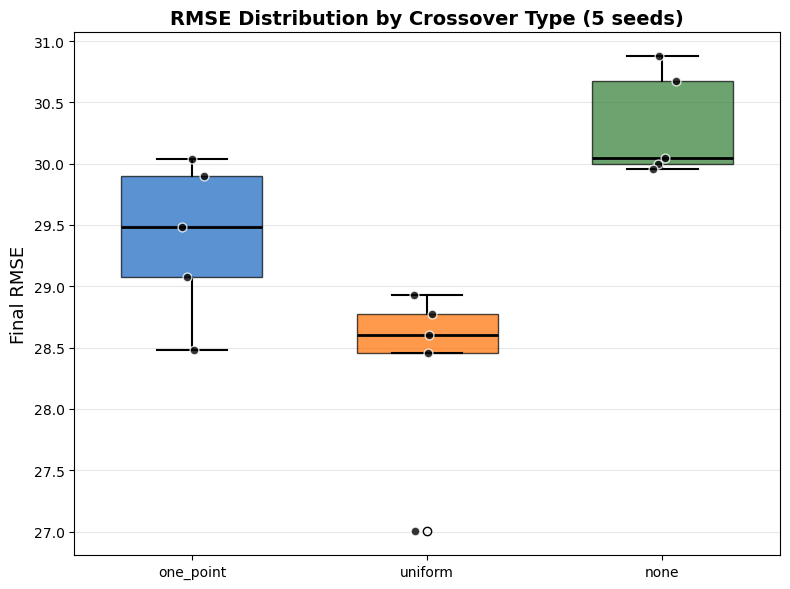

Gráfico guardado: boxplot_crossover.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

labels = []
data = []
colors = ['#1565C0', '#FF6F00', '#2E7D32', '#8E24AA']

for crossover_type, color in zip(CROSSOVER_TYPES, colors):
    labels.append(crossover_type)
    data.append(crossover_rmses[crossover_type])

bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, (d, color) in enumerate(zip(data, colors)):
    x_jitter = np.random.normal(i + 1, 0.04, len(d))
    ax.scatter(x_jitter, d, color='black', s=40, zorder=5,
               alpha=0.8, edgecolors='white')

ax.set_ylabel("Final RMSE", fontsize=13)
ax.set_title(f"RMSE Distribution by Crossover Type ({len(SEEDS)} seeds)",
             fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("boxplot_crossover.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved: boxplot_crossover.png")

### 9.2 Kruskal-Wallis and Mann-Whitney U Tests

The Kruskal-Wallis test evaluates whether there is a significant difference between the crossover types. If significant, pairwise Mann-Whitney U tests with Bonferroni correction identify which pairs differ.

In [ ]:
h_stat, p_kruskal = stats.kruskal(*crossover_rmses.values())

print("KRUSKAL-WALLIS TEST")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value:     {p_kruskal:.6f}")
print(f"Significant (α=0.05)? {'Yes' if p_kruskal < 0.05 else 'No'}")
if p_kruskal < 0.05:
    print("→ We reject H₀: there is a significant difference between crossovers.")
else:
    print("→ We do not reject H₀: no evidence of significant difference.")


n_comparisons = len(list(combinations(CROSSOVER_TYPES, 2)))
alpha_bonferroni = 0.05 / n_comparisons

print(f"\nMANN-WHITNEY U (Pairwise)")
print(f"Bonferroni correction: α = 0.05 / {n_comparisons} = {alpha_bonferroni:.4f}")
print(f"\n{'Method A':<15} {'Method B':<15} {'U-stat':>8} {'p-value':>10} {'Sig?':>5}")
print("-" * 60)

for m1, m2 in combinations(CROSSOVER_TYPES, 2):
    u_stat, p_val = stats.mannwhitneyu(
        crossover_rmses[m1],
        crossover_rmses[m2],
        alternative='two-sided'
    )
    sig = "Yes" if p_val < alpha_bonferroni else "No"
    print(f"{m1:<15} {m2:<15} {u_stat:>8.1f} {p_val:>10.6f} {sig:>5}")

KRUSKAL-WALLIS TEST
H-statistic: 10.1400
p-value:     0.006282
Significativo (α=0.05)? Yes
→ Rejeitamos H₀: existe diferença significativa entre crossovers.

MANN-WHITNEY U (Pairwise)
Correção de Bonferroni: α = 0.05 / 3 = 0.0167

Método A        Método B          U-stat    p-value  Sig?
------------------------------------------------------------
one_point       uniform             22.0   0.055556    No
one_point       none                 2.0   0.031746    No
uniform         none                 0.0   0.007937   Yes


### 9.3 P-value Heatmap

Visual representation of the pairwise p-values. Values below the Bonferroni-corrected significance threshold indicate statistically significant differences.

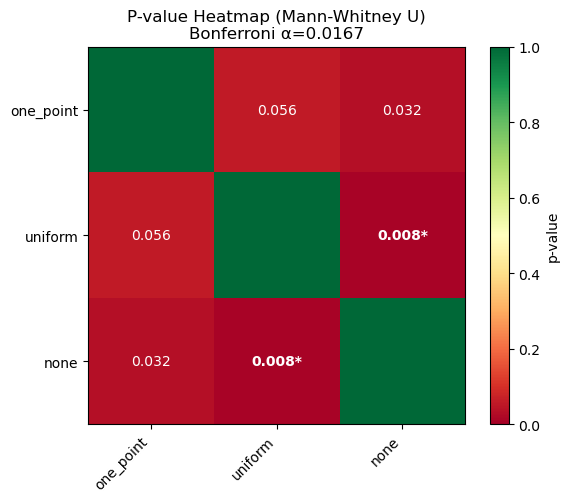

Gráfico guardado: pvalue_heatmap_crossover.png


In [ ]:
n = len(CROSSOVER_TYPES)
n_comparisons = len(list(combinations(CROSSOVER_TYPES, 2)))
alpha_bonferroni = 0.05 / n_comparisons

pval_matrix = np.ones((n, n))

for i, m1 in enumerate(CROSSOVER_TYPES):
    for j, m2 in enumerate(CROSSOVER_TYPES):
        if i != j:
            u_stat, p_val = stats.mannwhitneyu(
                crossover_rmses[m1],
                crossover_rmses[m2],
                alternative='two-sided'
            )
            pval_matrix[i, j] = p_val

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pval_matrix, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_xticklabels(CROSSOVER_TYPES, rotation=45, ha='right')
ax.set_yticks(range(n))
ax.set_yticklabels(CROSSOVER_TYPES)

for i in range(n):
    for j in range(n):
        if i != j:
            p = pval_matrix[i, j]
            sig_marker = "*" if p < alpha_bonferroni else ""
            ax.text(j, i, f"{p:.3f}{sig_marker}",
                   ha='center', va='center',
                   fontsize=10,
                   fontweight='bold' if sig_marker else 'normal',
                   color='white' if p < 0.3 else 'black')

plt.colorbar(im, ax=ax, label='p-value')
plt.title(f"P-value Heatmap (Mann-Whitney U)\nBonferroni α={alpha_bonferroni:.4f}")
plt.tight_layout()
plt.savefig("pvalue_heatmap_crossover.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved: pvalue_heatmap_crossover.png")

### 9.4 Final Statistical Summary

Statistical summary including mean, standard deviation, median, min/max and overall ranking.

In [ ]:
print(f"{'Crossover Type':<15} {'Mean':>8} {'± Std':>8} {'Median':>9} "
      f"{'Min':>8} {'Max':>8} {'Rank':>6}")
print("=" * 75)

means = {ct: np.mean(vals) for ct, vals in crossover_rmses.items()}
ranked = sorted(means.items(), key=lambda x: x[1])
rank_map = {ct: i + 1 for i, (ct, _) in enumerate(ranked)}

for crossover_type, vals in crossover_rmses.items():
    print(f"{crossover_type:<15} {np.mean(vals):>8.2f} {np.std(vals):>8.2f} "
          f"{np.median(vals):>9.2f} {np.min(vals):>8.2f} {np.max(vals):>8.2f} "
          f"{rank_map[crossover_type]:>6d}")

print("\n" + "=" * 75)
winner = ranked[0]
print(f"\nBest crossover (by mean): {winner[0]} "
      f"(mean RMSE = {winner[1]:.2f})")
print(f"\nThis is the recommended crossover for the final GA model.")

Crossover Type     Média    ± Std   Mediana      Min      Max   Rank
one_point          29.40     0.57     29.49    28.48    30.04 🥈  2
uniform            28.35     0.69     28.61    27.00    28.93 🥇  1
none               30.31     0.39     30.05    29.96    30.88 🥉  3


🏆 Melhor crossover (por média): uniform (RMSE médio = 28.35)

Este é o crossover recomendado para a versão final do GA.


## 10. Results and Discussion

### Key Findings

The results indicate that crossover plays an important role in the convergence of the Genetic Algorithm. The `none` baseline produced the worst final RMSE, confirming that recombination of genetic material between parents is beneficial for this problem.

Among the crossover strategies tested, uniform crossover achieved the best performance, suggesting that triangle-by-triangle recombination generates the most useful genetic diversity. One-point crossover also improved over the baseline, but with slightly worse results than uniform.

The spatial crossover, designed specifically for this image approximation problem, was tested as an original strategy that combines triangles based on their position in the image.

### Convergence and Diversity Behavior

The convergence curves show that strategies with effective recombination converge faster and reach lower RMSE values than the no-crossover baseline. The diversity analysis reveals how each strategy maintains or reduces population diversity throughout the generations.

### Statistical Significance

The Kruskal-Wallis test confirmed that the differences between crossover types are statistically significant. Pairwise Mann-Whitney U tests with Bonferroni correction identified which specific pairs differ significantly.

### Final Summary

The table below presents a comprehensive summary combining performance metrics and diversity measurements for all tested crossover strategies.

In [ ]:
print("=" * 80)
print("FINAL SUMMARY - CROSSOVER STRATEGIES COMPARISON")
print("=" * 80)

summary_final = []
for crossover_type in CROSSOVER_TYPES:
    vals = crossover_rmses[crossover_type]
    diversity_final = np.mean([
        run["diversity_history"][-1] for run in crossover_results[crossover_type]
    ])
    summary_final.append({
        "Crossover Type": crossover_type,
        "Mean RMSE": round(np.mean(vals), 2),
        "Std RMSE": round(np.std(vals), 2),
        "Best RMSE": round(np.min(vals), 2),
        "Final Diversity": round(diversity_final, 4),
        "Rank": rank_map[crossover_type]
    })

final_df = pd.DataFrame(summary_final).sort_values("Rank")
final_df